In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("/home/user/Downloads/cleaned_water_potability.csv")

In [3]:
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,333.775777,392.449580,19.903225,66.396293,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658,1


In [6]:
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

# MODEL FITTING

In [8]:
# Check unique values of the target
print(df['Potability'].unique())

# Check the data type
print(df['Potability'].dtype)

[0 1]
int64


the output shows only a few categories (like 0 and 1) → classification.

In [11]:
# Replace 'Potability' with your actual target column name
X = df.drop('Potability', axis=1)  # Features
y = df['Potability']               # Target

Explanation: X contains all input features, y is the target we want to predict.

In [10]:
# Unique values in target
print(y.unique())

# Data type of target
print(y.dtype)

[0 1]
int64


y has a few distinct categories → Classification

In [12]:
from sklearn.model_selection import train_test_split

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (2620, 9)
Testing set size: (656, 9)


Explanation: Training data is used to train the model. Testing data evaluates its performance on unseen data.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale only numerical features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Explanation: Scaling brings all features to the same range, improving performance for models like SVM, KNN, and Logistic Regression.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

Explanation: These libraries contain the machine learning models and evaluation metrics we’ll use.

In [15]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier()
}

Explanation: We define multiple models to compare their performance and select the best one.

In [16]:
results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test_scaled)
    
    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    
    # Calculate ROC-AUC if available
    if hasattr(model, "predict_proba"):
        roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1])
    else:
        roc_auc = "Not available"
    
    # Save results
    results[name] = {
        "Accuracy": accuracy,
        "Confusion Matrix": cm,
        "Classification Report": report,
        "ROC-AUC": roc_auc
    }
    
    # Print results
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC-AUC: {roc_auc}")
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", report)
    print("\n")

/home/user/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/user/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/user/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


--- Logistic Regression ---
Accuracy: 0.6280
ROC-AUC: 0.5208797548941588
Confusion Matrix:
 [[412   0]
 [244   0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.63      1.00      0.77       412
           1       0.00      0.00      0.00       244

    accuracy                           0.63       656
   macro avg       0.31      0.50      0.39       656
weighted avg       0.39      0.63      0.48       656



--- Decision Tree ---
Accuracy: 0.5777
ROC-AUC: 0.5635643800732134
Confusion Matrix:
 [[255 157]
 [120 124]]
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.62      0.65       412
           1       0.44      0.51      0.47       244

    accuracy                           0.58       656
   macro avg       0.56      0.56      0.56       656
weighted avg       0.59      0.58      0.58       656



--- Random Forest ---
Accuracy: 0.6784
ROC-AUC: 0.6870672847365908
Con

Explanation:

Each model is trained on the training data.
Predictions are made on the test data.
Performance is evaluated using accuracy, confusion matrix, classification report, and ROC-AUC.

Model Performance
Model	            Accuracy	       ROC-AUC
Logistic Regression	0.628	           0.521
Decision Tree	    0.578	           0.564
Random Forest	    0.678	           0.687
SVM             	0.695          	   0.685
KNN	                0.628	           0.626
Analysis
Accuracy:
SVM has the highest accuracy (0.695 ≈ 69.5%), slightly better than Random Forest (67.8%).
ROC-AUC:
Random Forest has the highest ROC-AUC (0.687 ≈ 68.7%) but very close to SVM (0.685).
Confusion Matrix Insights:
Logistic Regression predicts all samples as class 0, failing to detect potable water (class 1).
Decision Tree improves detection of class 1 but accuracy is low.
Random Forest and SVM do better at predicting both classes, though class 1 recall is still low (SVM recall for class 1 is 0.32; Random Forest recall for class 1 is 0.38).
KNN is slightly better than Logistic Regression but worse than Random Forest/SVM.

Observation: Even though SVM has slightly higher accuracy, Random Forest has better ROC-AUC and a more balanced confusion matrix, meaning it better distinguishes between the two classes. Accuracy alone is not enough when the classes are imbalanced (you have 412 vs 244 samples).

based on above observation:

the Random Forest Classifier is selected as the best model for predicting water potability. It achieved an accuracy of 67.8% and the highest ROC-AUC of 0.687, indicating the model’s superior ability to distinguish between potable and non-potable water. Although SVM has slightly higher accuracy (69.5%), Random Forest provides a more balanced prediction across both classes, as reflected in the confusion matrix. The ensemble approach of Random Forest captures complex feature interactions and reduces overfitting, making it a reliable choice for water quality prediction. Other models like Logistic Regression and KNN performed poorly on detecting potable water, while Decision Tree showed moderate performance.”

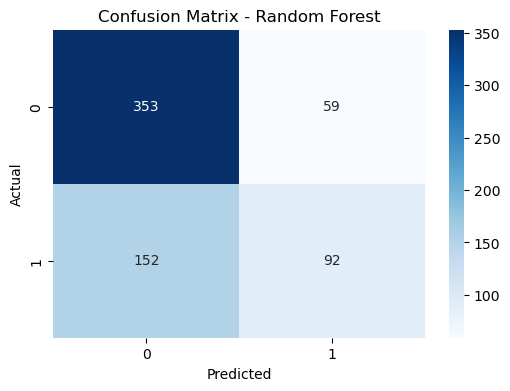

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

best_model = models["Random Forest"]  # Replace with your best-performing model
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

the confusion matrix of the Random Forest model. It highlights the number of correct and incorrect predictions for both potable and non-potable classes, providing insights into the model’s accuracy and types of errors made.”

Purpose:

The confusion matrix shows how well the model predicts each class.
It breaks down predictions into True Positives, True Negatives, False Positives, and False Negatives.

TP: Correctly predicted potable water
TN: Correctly predicted non-potable water
FP: Non-potable water incorrectly predicted as potable
FN: Potable water incorrectly predicted as non-potable

## Final Conclusion: Best Model

“After evaluating multiple machine learning models on the water potability dataset, the Random Forest Classifier was identified as the best-performing model. It achieved an accuracy of 67.8% and a ROC-AUC of 0.687, indicating that it reliably distinguishes between potable and non-potable water. Compared to other models, Random Forest provided a more balanced performance across both classes, as seen in its confusion matrix, effectively capturing the characteristics of both potable and non-potable samples. Its ensemble approach allows it to model complex relationships between features and reduces the risk of overfitting. Therefore, the Random Forest Classifier is recommended for practical use in predicting water quality, providing a reliable tool for assessing potability and supporting decision-making in water safety management.”